# Estimate CNMFe parameters

Walks the four pipeline stages (MC, downsample, init, temporal/merge/eval) and
for each tunable parameter renders one or two diagnostics and prints a
**suggested value**. Each suggestion goes into `suggested_params`; the final
cell writes them as `params.json` for the staged CLIs (`run_mc.py`,
`run_extract.py`).

**Inputs are stage-specific** — fill the path each section needs and run the
section. Sections are independent (you can skip ones you don't have inputs for):

- Stage 1 (MC params): AVI folder
- Stage 2 (downsample): AVI folder + indicator decay time
- Stage 3 (init): `mc.zarr` from a previous MC run
- Stage 4 (temporal/merge/eval): `results/` dir from a previous `fit_extract` run

Suggestions are heuristics, not ground truth — use the figures to sanity-check
every value before adopting it.

## 0. Imports + accumulator

In [1]:
import json
import sys
import time
from pathlib import Path

import av
import matplotlib.pyplot as plt
import numpy as np
from skimage.feature import blob_log

PROJECT_ROOT = Path('/home/fs539/code/simpler_cnmfe')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from minicnmfe.initialization import detect_seeds, greedy_corr_pnr
from minicnmfe.io import open_zarr
from minicnmfe.motion_correction import estimate_shifts
from minicnmfe.pipeline import CNMFe, CNMFeParams
from minicnmfe.preprocess import correlation_pnr
from minicnmfe.temporal import estimate_ar_params
from concat_avis_to_zarr import _numeric_key

# All suggestions accumulate here; final cell dumps them as params.json.
suggested_params: dict = {}
print('imports ok')

imports ok


## Stage 1 — MC params (`mc_gSig_filt`, `max_shift`, `border_px`)

Decodes a strided sample of frames straight from the AVIs (no zarr) and uses
two diagnostics: a temporal-std projection to estimate neuron radius (for
`mc_gSig_filt`), and per-frame shift estimates against a median template (for
`max_shift`). Suggestions are in **native** (full-resolution) units — they
will be rescaled by `CNMFeParams.downscaled(ssub, tsub)` at run time, so set
them once for the native AVIs and let the downsample stage handle the rest.

In [2]:
# --- EDIT ME -----------------------------------------------------------------
AVI_DIR = Path(
    '/media/server/archive/projects/2023_intercontext/ToneComparison/'
    'data/0_raw/20260520_m0000159_som_1145/miniscope_video'
)
N_TEMPLATE_AVIS = 8        # how many AVIs to sample for the temporal-std proj
STRIDE_WITHIN_AVI = 50     # take every Nth frame inside each sampled AVI
N_SHIFT_FRAMES = 200       # frames used for the per-frame shift histogram
# -----------------------------------------------------------------------------

avis = sorted(AVI_DIR.glob('*.avi'), key=_numeric_key)
avis = [p for p in avis if _numeric_key(p) >= 0]
assert avis, f'No numerically-named AVIs in {AVI_DIR}'
print(f'{len(avis)} AVI file(s) in {AVI_DIR}')

100 AVI file(s) in /media/server/archive/projects/2023_intercontext/ToneComparison/data/0_raw/20260520_m0000159_som_1145/miniscope_video


In [3]:
# Decode a strided sample of frames from a strided subset of AVIs into RAM.
# Same shape as the run_session.ipynb avi_mean_and_median helper, returns the
# raw stack so we can compute both std and median projections from it.
def decode_strided_sample(avi_paths, n_avis: int, stride: int) -> np.ndarray:
    k = min(n_avis, len(avi_paths))
    picks = np.linspace(0, len(avi_paths) - 1, k).astype(int)
    pool = []
    for i in picks:
        container = av.open(str(avi_paths[i]))
        try:
            stream = container.streams.video[0]
            stream.thread_type = 'FRAME'
            for j, frame in enumerate(container.decode(stream)):
                if j % stride == 0:
                    pool.append(frame.to_ndarray(format='gray8'))
        finally:
            container.close()
    return np.stack(pool, axis=0).astype(np.float32)

t0 = time.time()
sample = decode_strided_sample(avis, N_TEMPLATE_AVIS, STRIDE_WITHIN_AVI)
T_sample, H, W = sample.shape
print(f'sampled {T_sample} frames at {H}x{W}  ({time.time() - t0:.1f}s)')

std_img = sample.std(axis=0)
median_img = np.median(sample, axis=0)

sampled 146 frames at 600x600  (15.8s)


### 1.1 `mc_gSig_filt` — high-pass radius (native px)

The Gaussian-filter sigma for the MC high-pass should roughly match neuron
radius. Below: temporal-std projection of the sampled frames; `blob_log` finds
the brightest blobs and reports their fitted Gaussian sigma (in px). Suggested
value = median of fitted sigmas, rounded.

If the blobs trace blood vessels or the field-of-view border instead of
neurons, bump `STRIDE_WITHIN_AVI` (more diverse sample) or restrict the search
to a central crop.

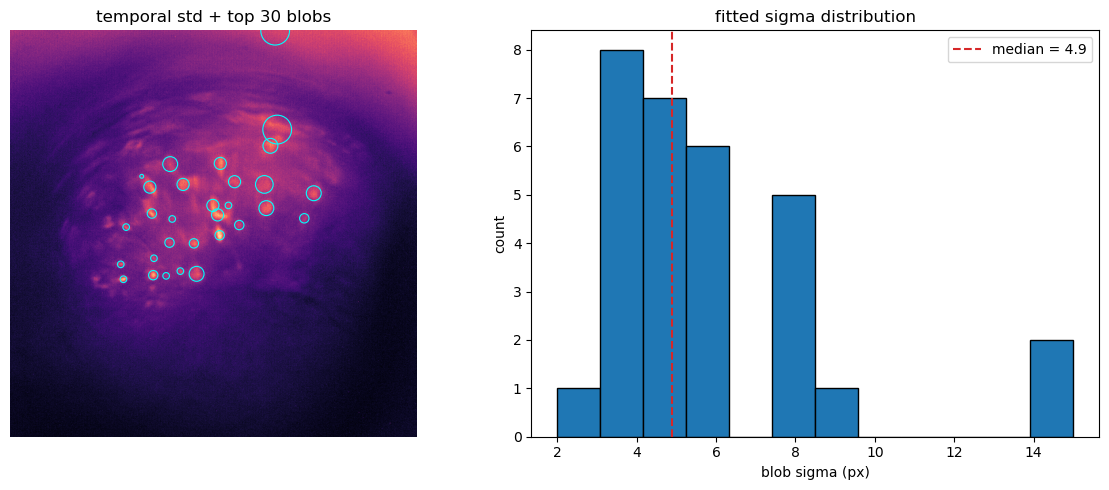


[suggested]  mc_gSig_filt = 5  (median blob sigma = 4.89 px)
             also use this as the native sigma seed for stage 3.1


In [4]:
# blob_log returns (y, x, sigma) for the dominant Gaussian-shaped bright spots.
# We normalise std_img to [0, 1] so the threshold is interpretable across
# recordings.
std_norm = (std_img - std_img.min()) / (std_img.max() - std_img.min() + 1e-8)
blobs = blob_log(std_norm, min_sigma=2, max_sigma=15, num_sigma=10, threshold=0.05)
if len(blobs) == 0:
    print('no blobs found; try lowering threshold or widening sigma range')
else:
    sigmas = blobs[:, 2]
    # Keep the top-N brightest blobs to bias toward real neurons
    scores = std_norm[blobs[:, 0].astype(int), blobs[:, 1].astype(int)]
    order = np.argsort(-scores)[:30]
    blobs_top = blobs[order]
    sigmas_top = sigmas[order]
    median_sigma = float(np.median(sigmas_top))
    mc_gSig_filt_suggested = int(round(median_sigma))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(std_img, cmap='magma')
    for y, x, s in blobs_top:
        axes[0].add_patch(plt.Circle((x, y), s * np.sqrt(2), color='cyan',
                                      fill=False, lw=0.8))
    axes[0].set_title(f'temporal std + top {len(blobs_top)} blobs')
    axes[0].axis('off')
    axes[1].hist(sigmas_top, bins=12, color='C0', edgecolor='k')
    axes[1].axvline(median_sigma, color='C3', ls='--', lw=1.5,
                    label=f'median = {median_sigma:.1f}')
    axes[1].set_xlabel('blob sigma (px)')
    axes[1].set_ylabel('count')
    axes[1].set_title('fitted sigma distribution')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    print(f'\n[suggested]  mc_gSig_filt = {mc_gSig_filt_suggested}  '
          f'(median blob sigma = {median_sigma:.2f} px)')
    print(f'             also use this as the native sigma seed for stage 3.1')
    suggested_params['mc_gSig_filt'] = mc_gSig_filt_suggested
    suggested_params['sigma'] = float(median_sigma)

### 1.2 `max_shift` — max permitted (dy, dx) (native px)

Estimates per-frame `(dy, dx)` against the strided-sample median, using the
high-pass filter implied by 1.1. Histogram of `|dy|` and `|dx|`; suggested
`max_shift` = 99th percentile + 2 px safety margin.

A wide / saturated histogram means the recording has more motion than
expected — the suggested cap will be conservative.

estimated 146 shifts  (4.0s, gSig_filt=5)


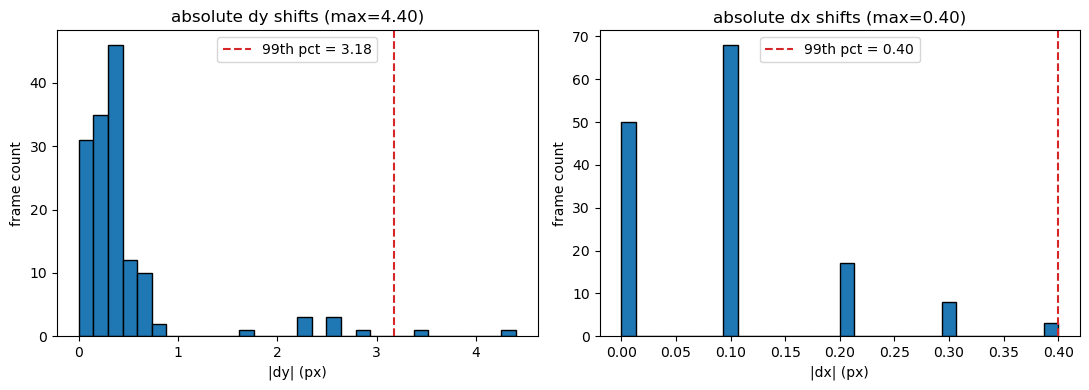


[suggested]  max_shift = (6, 3)  (99th-pct + 2 px margin)
[suggested]  border_px = 6  (= max of the above; safe to trim warpAffine fill artefacts)


In [5]:
# Use the median of the same sample as the reference template; we evaluate
# shifts on a (possibly larger) strided sample for the histogram.
if T_sample < N_SHIFT_FRAMES:
    shift_sample = sample
else:
    idx = np.linspace(0, T_sample - 1, N_SHIFT_FRAMES).astype(int)
    shift_sample = sample[idx]

g_filt = suggested_params.get('mc_gSig_filt', None)
t0 = time.time()
shifts = np.stack([
    estimate_shifts(f, median_img, upsample_factor=10,
                    max_shift=(50, 50), gSig_filt=g_filt)
    for f in shift_sample
])
print(f'estimated {len(shifts)} shifts  ({time.time() - t0:.1f}s, '
      f'gSig_filt={g_filt})')

abs_dy = np.abs(shifts[:, 0])
abs_dx = np.abs(shifts[:, 1])
p99_dy = float(np.percentile(abs_dy, 99))
p99_dx = float(np.percentile(abs_dx, 99))
max_shift_y = int(np.ceil(p99_dy)) + 2
max_shift_x = int(np.ceil(p99_dx)) + 2

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, vals, p99, lab in [(axes[0], abs_dy, p99_dy, 'dy'),
                            (axes[1], abs_dx, p99_dx, 'dx')]:
    ax.hist(vals, bins=30, color='C0', edgecolor='k')
    ax.axvline(p99, color='C3', ls='--', lw=1.5,
               label=f'99th pct = {p99:.2f}')
    ax.set_xlabel(f'|{lab}| (px)')
    ax.set_ylabel('frame count')
    ax.set_title(f'absolute {lab} shifts (max={vals.max():.2f})')
    ax.legend()
plt.tight_layout()
plt.show()

print(f'\n[suggested]  max_shift = ({max_shift_y}, {max_shift_x})  '
      f'(99th-pct + 2 px margin)')
print(f'[suggested]  border_px = {max(max_shift_y, max_shift_x)}  '
      f'(= max of the above; safe to trim warpAffine fill artefacts)')
suggested_params['max_shift'] = (max_shift_y, max_shift_x)
suggested_params['border_px'] = max(max_shift_y, max_shift_x)

## Stage 2 — Downsample (`ssub`, `tsub`)

Two simple rules:

- **`ssub`**: keep neuron FWHM ≥ ~4 px on the binned grid, otherwise neurons
  collapse to a single pixel and `correlation_pnr` loses signal.
- **`tsub`**: keep the effective frame period below `decay_time_ms / 2`, so
  the rising edge of a calcium transient is sampled at least twice.

Needs the FWHM from 1.1 and the indicator decay time (set below).

In [6]:
# --- EDIT ME -----------------------------------------------------------------
FRAME_RATE_HZ = 20.0     # acquisition frame rate (native)
# Indicator single-AP decay time, ms (see CLAUDE.md table):
#   GCaMP6f ~140  jGCaMP7f ~160  jGCaMP8f ~70   jGCaMP8m ~180
#   jGCaMP8s ~350 GCaMP6s ~1000  GCaMP7s ~1000
DECAY_TIME_MS = 180.0
# -----------------------------------------------------------------------------

sigma_native = suggested_params.get('sigma', None)
if sigma_native is None:
    raise RuntimeError('run stage 1.1 first so we know the native neuron sigma')
fwhm_native = 2.355 * sigma_native

print(f'native neuron FWHM ≈ {fwhm_native:.2f} px')
print(f'native frame rate   = {FRAME_RATE_HZ:g} Hz  (dt = {1000/FRAME_RATE_HZ:.1f} ms)')
print(f'indicator decay     = {DECAY_TIME_MS:g} ms')

print('\nssub candidates:')
print(f'  {"ssub":>4s}  {"FWHM_ds (px)":>12s}  ok?')
ssub_ok = []
for ssub in (1, 2, 3, 4):
    fwhm_ds = fwhm_native / ssub
    ok = fwhm_ds >= 4.0
    print(f'  {ssub:>4d}  {fwhm_ds:>12.2f}  {"✓" if ok else "✗ too small"}')
    if ok:
        ssub_ok.append(ssub)
ssub_suggested = max(ssub_ok) if ssub_ok else 1

print('\ntsub candidates:')
print(f'  {"tsub":>4s}  {"dt_ds (ms)":>10s}  {"dt_ds / decay":>14s}  ok?')
tsub_ok = []
for tsub in (1, 2, 3, 4, 5):
    dt_ds = (1000.0 / FRAME_RATE_HZ) * tsub
    ratio = dt_ds / DECAY_TIME_MS
    ok = dt_ds <= DECAY_TIME_MS / 2
    print(f'  {tsub:>4d}  {dt_ds:>10.1f}  {ratio:>14.2f}  '
          f'{"✓" if ok else "✗ under-samples decay"}')
    if ok:
        tsub_ok.append(tsub)
tsub_suggested = max(tsub_ok) if tsub_ok else 1

print(f'\n[suggested]  ssub = {ssub_suggested}   '
      f'tsub = {tsub_suggested}')
print(f'             frame_rate_hz = {FRAME_RATE_HZ}  '
      f'decay_time_ms = {DECAY_TIME_MS}')
suggested_params['frame_rate_hz'] = float(FRAME_RATE_HZ)
suggested_params['decay_time_ms'] = float(DECAY_TIME_MS)
# ssub / tsub are not CNMFeParams fields — they go into the run cell separately.
suggested_params['_ssub'] = int(ssub_suggested)
suggested_params['_tsub'] = int(tsub_suggested)

native neuron FWHM ≈ 11.51 px
native frame rate   = 20 Hz  (dt = 50.0 ms)
indicator decay     = 180 ms

ssub candidates:
  ssub  FWHM_ds (px)  ok?
     1         11.51  ✓
     2          5.76  ✓
     3          3.84  ✗ too small
     4          2.88  ✗ too small

tsub candidates:
  tsub  dt_ds (ms)   dt_ds / decay  ok?
     1        50.0            0.28  ✓
     2       100.0            0.56  ✗ under-samples decay
     3       150.0            0.83  ✗ under-samples decay
     4       200.0            1.11  ✗ under-samples decay
     5       250.0            1.39  ✗ under-samples decay

[suggested]  ssub = 2   tsub = 1
             frame_rate_hz = 20.0  decay_time_ms = 180.0


## Stage 3 — Init (`sigma`, `min_corr`, `min_pnr`, `min_pixel`)

Operates on an existing `mc.zarr`. If you ran the downsample-once workflow,
this `mc.zarr` is at the downsampled grid and the suggested `sigma` /
`min_pixel` will already be expressed on that grid — don't pass them through
`downscaled()` again.

All four diagnostics share one strided sample of `mc.zarr` loaded into RAM
(default 400 frames — enough for the seed map, light enough for laptops).

In [7]:
# --- EDIT ME -----------------------------------------------------------------
MC_ZARR = Path(
    '/media/server/archive/projects/2023_intercontext/ToneComparison/'
    'data/1_preprocessed/20260520_m0000159_som_1145/miniscope_video/mc.zarr'
)
N_INIT_FRAMES = 400        # strided sample loaded into RAM for CORR/PNR
# -----------------------------------------------------------------------------

mc = open_zarr(MC_ZARR)
T_mc, H_mc, W_mc = mc.shape
idx = np.linspace(0, T_mc - 1, min(T_mc, N_INIT_FRAMES)).astype(int)
t0 = time.time()
mc_sample = np.stack([np.asarray(mc[int(i)]) for i in idx]).astype(np.float32)
print(f'mc.zarr: {mc.shape}  dtype={mc.dtype}')
print(f'loaded {len(mc_sample)} strided frames  ({time.time() - t0:.1f}s)')

mc.zarr: (49643, 300, 300)  dtype=float32
loaded 400 strided frames  (194.8s)


### 3.1 `sigma` — neuron radius on the extraction grid

Computes CORR·PNR with an initial sigma guess, then refits `sigma` from
`blob_log` on the product image. If the recording was downsampled, the seed is
the rescaled value from 1.1; otherwise it falls back to a sensible default.
Suggested `sigma` = median of the fitted blob sigmas.

seed sigma for CORR/PNR: 2.44 px
CORR/PNR computed  (6.4s)


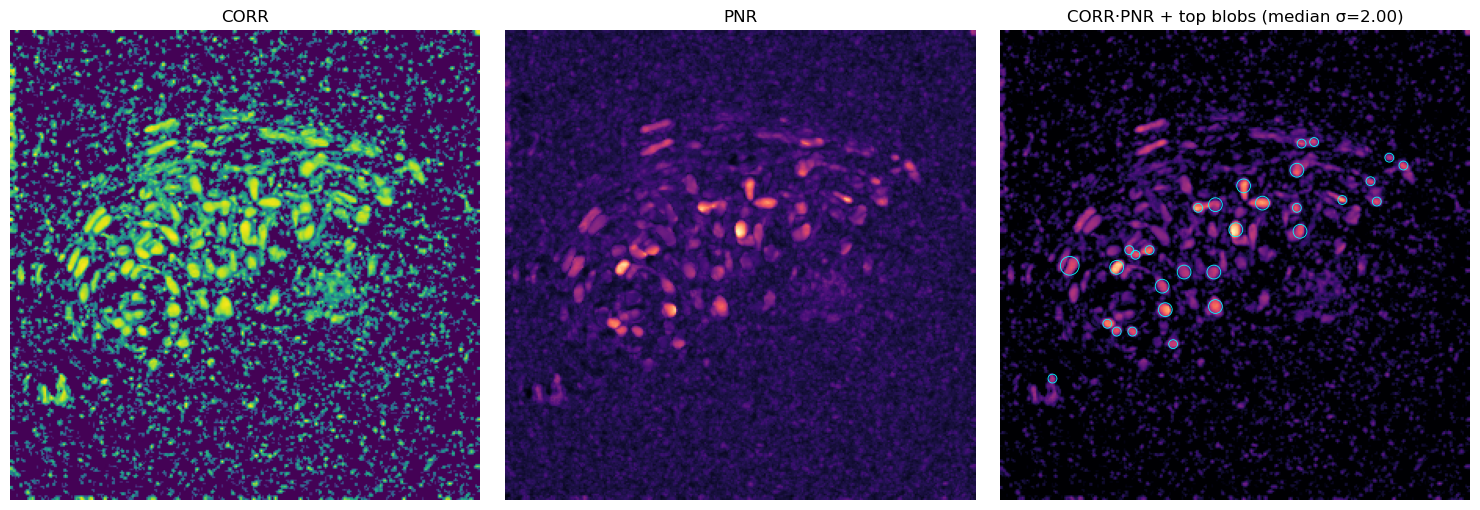


[suggested]  sigma = 2.00  (on the EXTRACTION grid)


In [8]:
# Seed sigma: try the value we suggested in stage 1.1 (downsample-aware),
# otherwise fall back to 4.0 px on the extraction grid.
ssub_ctx = suggested_params.get('_ssub', 1)
if 'sigma' in suggested_params and ssub_ctx > 1:
    sigma_seed = max(2.0, suggested_params['sigma'] / ssub_ctx)
elif 'sigma' in suggested_params:
    sigma_seed = suggested_params['sigma']
else:
    sigma_seed = 4.0
print(f'seed sigma for CORR/PNR: {sigma_seed:.2f} px')

t0 = time.time()
cn, pnr = correlation_pnr(mc_sample, sigma=sigma_seed)
print(f'CORR/PNR computed  ({time.time() - t0:.1f}s)')

product = cn * pnr
product_n = (product - product.min()) / (product.max() - product.min() + 1e-8)
blobs3 = blob_log(product_n, min_sigma=2, max_sigma=12, num_sigma=10, threshold=0.05)
if len(blobs3) == 0:
    print('no blobs in CORR·PNR; keeping seed sigma')
    sigma_refit = sigma_seed
else:
    scores = product_n[blobs3[:, 0].astype(int), blobs3[:, 1].astype(int)]
    order = np.argsort(-scores)[:30]
    sigma_refit = float(np.median(blobs3[order, 2]))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cn, cmap='viridis'); axes[0].set_title('CORR'); axes[0].axis('off')
axes[1].imshow(pnr, cmap='magma'); axes[1].set_title('PNR'); axes[1].axis('off')
axes[2].imshow(product, cmap='magma')
if len(blobs3):
    for y, x, s in blobs3[order]:
        axes[2].add_patch(plt.Circle((x, y), s * np.sqrt(2),
                                     color='cyan', fill=False, lw=0.6))
axes[2].set_title(f'CORR·PNR + top blobs (median σ={sigma_refit:.2f})')
axes[2].axis('off')
plt.tight_layout()
plt.show()

print(f'\n[suggested]  sigma = {sigma_refit:.2f}  (on the EXTRACTION grid)')
# Overwrite the (native-grid) sigma stashed in stage 1 if we are on a
# downsampled mc.zarr; otherwise they will agree.
suggested_params['sigma'] = float(sigma_refit)
# Keep these images around for 3.2/3.3.
_cn, _pnr = cn, pnr

### 3.2 `min_corr` / `min_pnr` — seed thresholds

Top row: CORR and PNR images. Bottom-left: pixel-value histograms. Bottom-right:
heatmap of seed counts over a grid of (`min_corr`, `min_pnr`). The "knee" of
the seed-count surface is roughly where real seeds stop being added and noise
starts being recruited — we suggest the smallest pair where the seed count
drops below 30% of its peak.

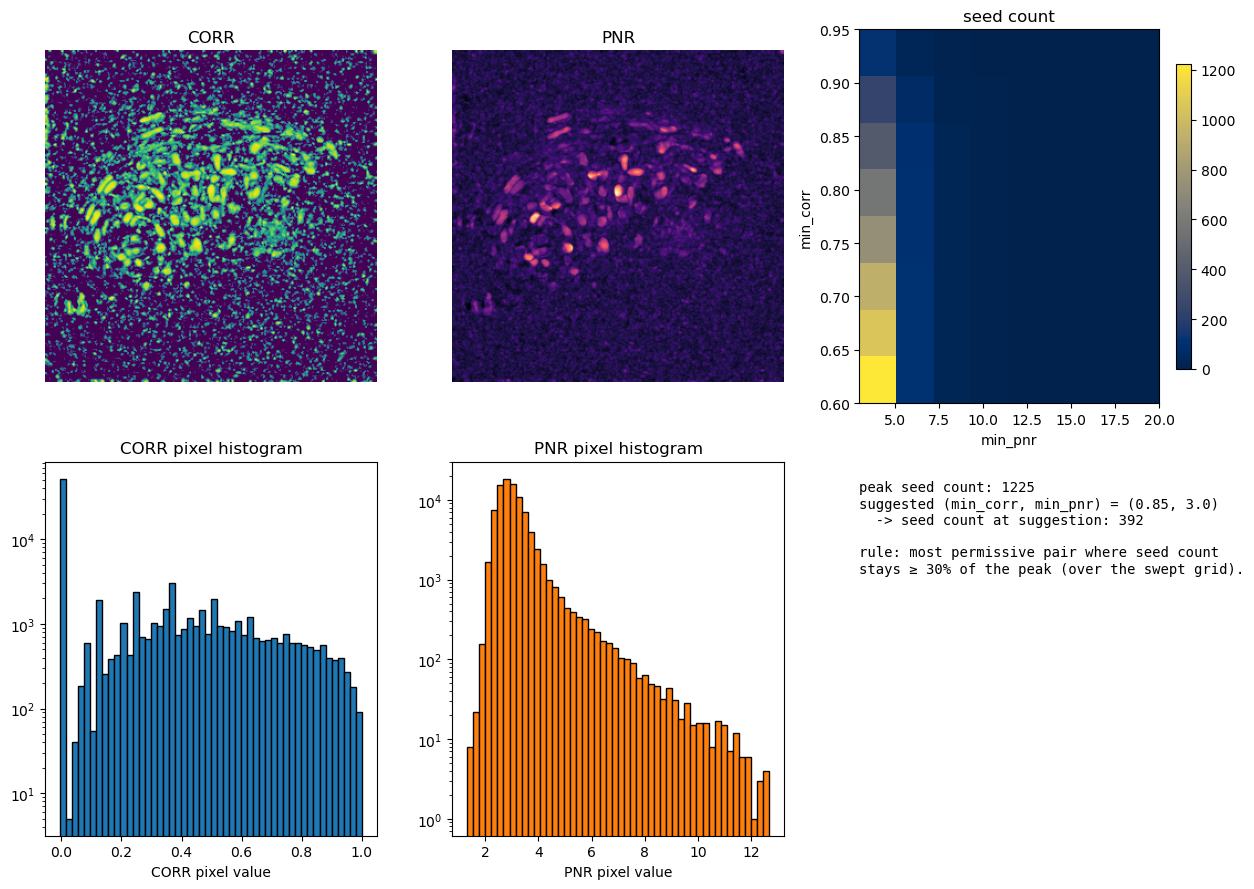


[suggested]  min_corr = 0.85  min_pnr = 3.0


In [9]:
corr_grid = np.linspace(0.6, 0.95, 8)
pnr_grid = np.linspace(3.0, 20.0, 8)
counts = np.zeros((len(corr_grid), len(pnr_grid)), dtype=int)
for i, mc_thr in enumerate(corr_grid):
    for j, mp_thr in enumerate(pnr_grid):
        seeds = detect_seeds(_cn, _pnr, float(mc_thr), float(mp_thr),
                              min_distance=max(2, int(suggested_params['sigma'])))
        counts[i, j] = len(seeds)

fig = plt.figure(figsize=(13, 9))
ax_cn  = plt.subplot2grid((2, 3), (0, 0))
ax_pnr = plt.subplot2grid((2, 3), (0, 1))
ax_hm  = plt.subplot2grid((2, 3), (0, 2))
ax_hc  = plt.subplot2grid((2, 3), (1, 0))
ax_hp  = plt.subplot2grid((2, 3), (1, 1))
ax_log = plt.subplot2grid((2, 3), (1, 2))

ax_cn.imshow(_cn, cmap='viridis'); ax_cn.set_title('CORR'); ax_cn.axis('off')
ax_pnr.imshow(_pnr, cmap='magma'); ax_pnr.set_title('PNR'); ax_pnr.axis('off')
im = ax_hm.imshow(counts, origin='lower', aspect='auto', cmap='cividis',
                   extent=[pnr_grid[0], pnr_grid[-1], corr_grid[0], corr_grid[-1]])
ax_hm.set_xlabel('min_pnr'); ax_hm.set_ylabel('min_corr')
ax_hm.set_title('seed count')
plt.colorbar(im, ax=ax_hm, fraction=0.046)

ax_hc.hist(_cn.ravel(), bins=50, color='C0', edgecolor='k')
ax_hc.set_xlabel('CORR pixel value'); ax_hc.set_yscale('log')
ax_hc.set_title('CORR pixel histogram')
ax_hp.hist(_pnr.ravel(), bins=50, color='C1', edgecolor='k')
ax_hp.set_xlabel('PNR pixel value'); ax_hp.set_yscale('log')
ax_hp.set_title('PNR pixel histogram')

# Knee-finding heuristic: keep the seed count above 30% of its peak,
# pick the most permissive pair that still falls below it for context.
peak = counts.max()
keep_mask = counts >= 0.3 * peak
if keep_mask.any():
    # Largest (min_corr, min_pnr) satisfying the floor — stricter is safer.
    ii = np.argwhere(keep_mask)
    pair_idx = ii[np.lexsort((-ii[:, 1], -ii[:, 0]))][0]
    min_corr_suggested = float(corr_grid[pair_idx[0]])
    min_pnr_suggested = float(pnr_grid[pair_idx[1]])
else:
    min_corr_suggested, min_pnr_suggested = 0.8, 10.0
ax_log.axis('off')
ax_log.text(0.0, 0.95,
    f'peak seed count: {peak}\n'
    f'suggested (min_corr, min_pnr) = ({min_corr_suggested:.2f}, {min_pnr_suggested:.1f})\n'
    f'  -> seed count at suggestion: '
    f'{counts[pair_idx[0], pair_idx[1]] if keep_mask.any() else "n/a"}\n\n'
    f'rule: most permissive pair where seed count\n'
    f'stays ≥ 30% of the peak (over the swept grid).',
    family='monospace', va='top', transform=ax_log.transAxes)
plt.tight_layout()
plt.show()

print(f'\n[suggested]  min_corr = {min_corr_suggested:.2f}  '
      f'min_pnr = {min_pnr_suggested:.1f}')
suggested_params['min_corr'] = min_corr_suggested
suggested_params['min_pnr'] = min_pnr_suggested

### 3.3 `min_pixel` — minimum footprint area

Runs a fast greedy init at the suggested (`sigma`, `min_corr`, `min_pnr`) and
histograms footprint pixel counts (number of pixels with `A[:,k] > 5% of
max`). Suggested `min_pixel` = 25th percentile — strict enough to reject
single-pixel artefacts, loose enough to keep dim neurons. The auto-evaluation
step (`auto_eval_snr_amp_thr`) is the real ghost-rejection filter; `min_pixel`
is just a hard floor.

greedy init: K=171 components  (9.0s)


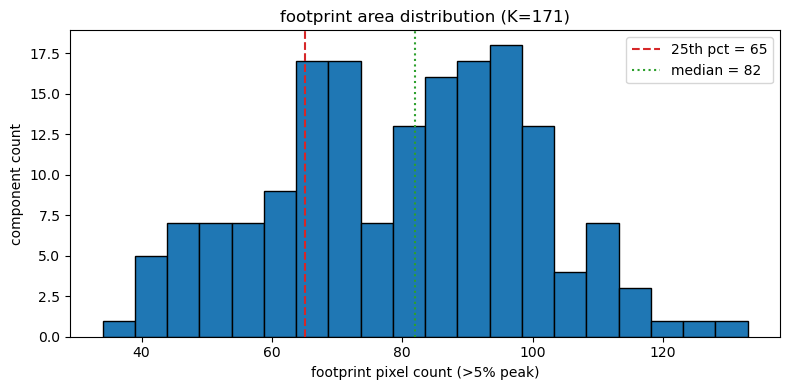


[suggested]  min_pixel = 65  (25th-pct footprint area)


In [10]:
# Greedy init on the strided sample is fast and a good predictor of the
# full-T footprint sizes. We use the suggested thresholds so we see the
# natural area distribution rather than artificially truncating it.
sigma_use = float(suggested_params['sigma'])
min_corr_use = float(suggested_params['min_corr'])
min_pnr_use = float(suggested_params['min_pnr'])

t0 = time.time()
A_init, _C_init, _C_raw_init, _centers = greedy_corr_pnr(
    mc_sample, sigma=sigma_use,
    min_corr=min_corr_use, min_pnr=min_pnr_use,
    max_neurons=200,
)
print(f'greedy init: K={A_init.shape[1]} components  ({time.time() - t0:.1f}s)')

if A_init.shape[1] == 0:
    print('no components found at suggested thresholds; lower min_corr/min_pnr')
else:
    K = A_init.shape[1]
    A2 = np.asarray(A_init.todense()).reshape(H_mc, W_mc, K)
    # Pixel count = pixels > 5% of footprint peak; matches the spirit of
    # threshold_footprint without running it.
    pixel_counts = np.array([
        int(((A2[..., k] > 0.05 * A2[..., k].max())).sum())
        for k in range(K)
    ])
    p25 = int(np.percentile(pixel_counts, 25))
    p50 = int(np.percentile(pixel_counts, 50))

    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    ax.hist(pixel_counts, bins=20, color='C0', edgecolor='k')
    ax.axvline(p25, color='C3', ls='--', lw=1.5, label=f'25th pct = {p25}')
    ax.axvline(p50, color='C2', ls=':', lw=1.5, label=f'median = {p50}')
    ax.set_xlabel('footprint pixel count (>5% peak)')
    ax.set_ylabel('component count')
    ax.set_title(f'footprint area distribution (K={K})')
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f'\n[suggested]  min_pixel = {p25}  (25th-pct footprint area)')
    suggested_params['min_pixel'] = p25

## Stage 4 — Temporal / merge / eval

Operates on a `results/` directory from a previous `fit_extract` + `evaluate`
run. We pull `C_raw`, `A`, `sn`, `accepted_mask`, and `eval_info` and use them
to estimate `decay_time_ms`, `g_prior_weight`, `merge_thr_corr`, and
`auto_eval_snr_amp_thr`.

In [11]:
# --- EDIT ME -----------------------------------------------------------------
RESULTS_DIR = Path(
    '/media/server/archive/projects/2023_intercontext/ToneComparison/'
    'data/2_processed/20260520_m0000159_som_1145/miniscope_video/results'
)
# -----------------------------------------------------------------------------

model = CNMFe.load(RESULTS_DIR)
C_raw = np.asarray(model.C_raw)
C = np.asarray(model.C)
K, T_full = C_raw.shape
params_used = model.params
fps_used = params_used.frame_rate_hz or suggested_params.get('frame_rate_hz')
decay_used = params_used.decay_time_ms or suggested_params.get('decay_time_ms')
print(f'loaded model: K={K}  T={T_full}')
print(f'              params.frame_rate_hz = {fps_used}  '
      f'params.decay_time_ms = {decay_used}')

loaded model: K=69  T=49643
              params.frame_rate_hz = 10.0  params.decay_time_ms = 180


### 4.1 `decay_time_ms` — indicator decay (ms)

Per-component Yule-Walker on `C_raw` (no prior, so we see what the data
actually supports). For each `g_yw`: `τ_frames = -1 / ln(g_yw)`, then
`τ_ms = τ_frames * 1000 / fps`. Suggestion = median τ.

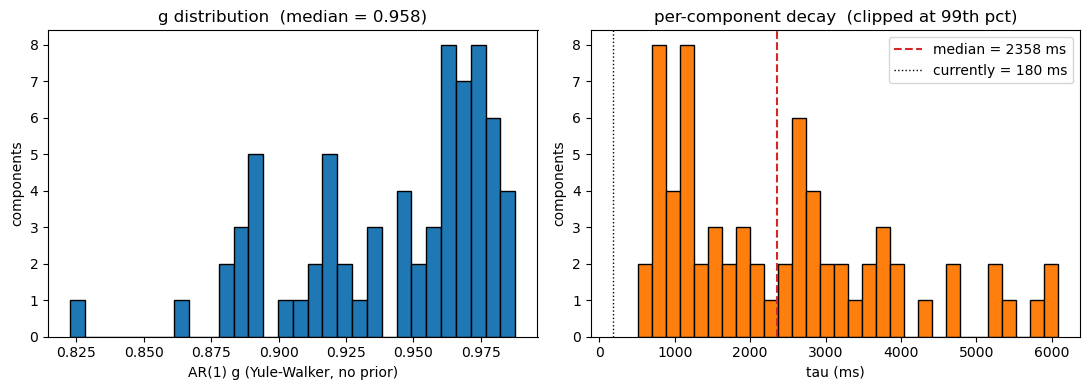


[suggested]  decay_time_ms = 2358  (median of per-component YW τ)


In [12]:
assert fps_used is not None, 'frame_rate_hz must be known to convert g -> tau_ms'

g_yw = np.empty(K, dtype=np.float32)
for k in range(K):
    g_arr, _ = estimate_ar_params(
        C_raw[k].astype(np.float64), p=1,
        g_prior=None, fudge_factor=1.0,        # raw YW, no shrinkage
        detrend_order=params_used.ar_detrend_order,
    )
    g_yw[k] = float(g_arr[0])

# Convert g -> tau (frames -> ms); clip g away from 1 so log is finite.
g_safe = np.clip(g_yw, 1e-4, 0.9995)
tau_frames = -1.0 / np.log(g_safe)
tau_ms = tau_frames * 1000.0 / fps_used
tau_med = float(np.median(tau_ms))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(g_yw, bins=30, color='C0', edgecolor='k')
axes[0].set_xlabel('AR(1) g (Yule-Walker, no prior)')
axes[0].set_ylabel('components')
axes[0].set_title(f'g distribution  (median = {np.median(g_yw):.3f})')
axes[1].hist(tau_ms[tau_ms < np.percentile(tau_ms, 99)],
             bins=30, color='C1', edgecolor='k')
axes[1].axvline(tau_med, color='C3', ls='--', lw=1.5,
                label=f'median = {tau_med:.0f} ms')
axes[1].axvline(decay_used or 0, color='k', ls=':', lw=1.0,
                label=f'currently = {decay_used} ms')
axes[1].set_xlabel('tau (ms)')
axes[1].set_ylabel('components')
axes[1].set_title('per-component decay  (clipped at 99th pct)')
axes[1].legend()
plt.tight_layout()
plt.show()

print(f'\n[suggested]  decay_time_ms = {tau_med:.0f}  '
      f'(median of per-component YW τ)')
suggested_params['decay_time_ms'] = float(round(tau_med))
suggested_params['frame_rate_hz'] = float(fps_used)

### 4.2 `g_prior_weight` — shrinkage strength

Compares each component's `g_yw` to the target `g_target = exp(-1 / (fps ·
τ/1000))` derived from `decay_time_ms`. Tight clustering around `g_target`
→ low weight is fine. Wide / drift-heavy spread → push the weight toward 1
so noise can't drift `g` away from the physical bound.

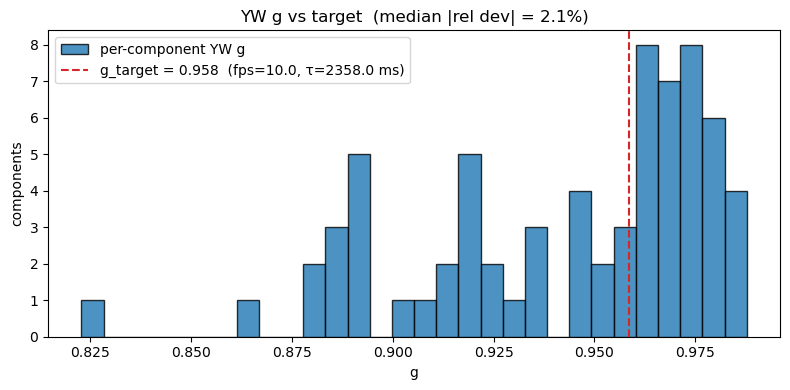


[suggested]  g_prior_weight = 0.3  (spread=2.1%)


In [13]:
decay_ms = float(suggested_params['decay_time_ms'])
g_target = float(np.exp(-1.0 / (fps_used * decay_ms / 1000.0)))

# Distance from target, expressed as fractional deviation.
rel_dev = (g_yw - g_target) / g_target
spread = float(np.median(np.abs(rel_dev)))

# Heuristic: 0.3 if tight (<5% median deviation),
#            0.5 if moderate (5–15%), 0.7 otherwise.
if spread < 0.05:
    weight_suggested = 0.3
elif spread < 0.15:
    weight_suggested = 0.5
else:
    weight_suggested = 0.7

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.hist(g_yw, bins=30, color='C0', edgecolor='k', alpha=0.8, label='per-component YW g')
ax.axvline(g_target, color='C3', ls='--', lw=1.5,
           label=f'g_target = {g_target:.3f}  (fps={fps_used}, τ={decay_ms} ms)')
ax.set_xlabel('g'); ax.set_ylabel('components')
ax.set_title(f'YW g vs target  (median |rel dev| = {spread*100:.1f}%)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\n[suggested]  g_prior_weight = {weight_suggested}  '
      f'(spread={spread*100:.1f}%)')
suggested_params['g_prior_weight'] = float(weight_suggested)

### 4.3 `merge_thr_corr` — pairwise-correlation merge threshold

Pearson correlation between every pair of `C_raw` traces. The bulk sits near
0 (uncorrelated neurons); a tail above ~0.7 is what `merge_components` is
designed to catch. The suggestion is the **lowest** of {0.85, the 99th
percentile} so we don't sweep up modestly correlated real neighbours.

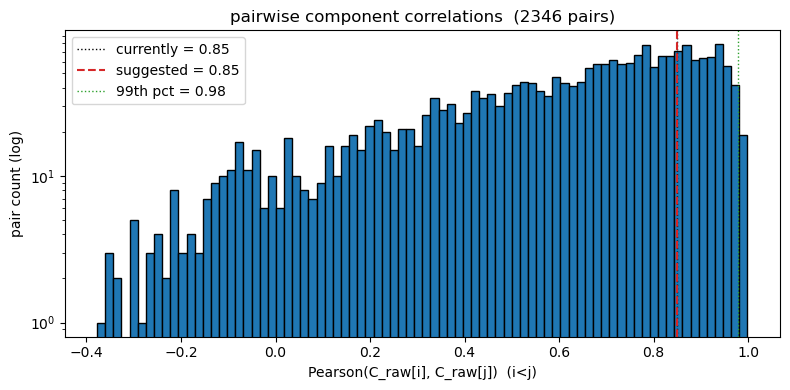


[suggested]  merge_thr_corr = 0.85  (516 pairs above this threshold)


In [14]:
# Pearson via normalised dot product; symmetric, exclude diagonal.
C0 = C_raw - C_raw.mean(axis=1, keepdims=True)
norms = np.linalg.norm(C0, axis=1, keepdims=True) + 1e-8
C0n = C0 / norms
R = C0n @ C0n.T
iu = np.triu_indices(K, k=1)
rs = R[iu]

current_thr = float(params_used.merge_thr_corr)
p99 = float(np.percentile(rs, 99))
merge_thr_suggested = float(min(0.85, max(p99, 0.7)))

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.hist(rs, bins=80, color='C0', edgecolor='k')
ax.set_yscale('log')
ax.axvline(current_thr, color='k', ls=':', lw=1.0,
           label=f'currently = {current_thr:.2f}')
ax.axvline(merge_thr_suggested, color='C3', ls='--', lw=1.5,
           label=f'suggested = {merge_thr_suggested:.2f}')
ax.axvline(p99, color='C2', ls=':', lw=1.0, label=f'99th pct = {p99:.2f}')
ax.set_xlabel('Pearson(C_raw[i], C_raw[j])  (i<j)')
ax.set_ylabel('pair count (log)')
ax.set_title(f'pairwise component correlations  ({len(rs)} pairs)')
ax.legend()
plt.tight_layout()
plt.show()

n_above = int((rs > merge_thr_suggested).sum())
print(f'\n[suggested]  merge_thr_corr = {merge_thr_suggested:.2f}  '
      f'({n_above} pairs above this threshold)')
suggested_params['merge_thr_corr'] = merge_thr_suggested

### 4.4 `auto_eval_snr_amp_thr` — ghost-rejection threshold

Histogram of the per-component SNR score (from `model.eval_info`) plus six
footprints just above and six just below the current threshold so you can see
what is at the boundary. Real neurons typically score 10–70; ghosts cluster
below ~2. The suggestion picks the centre of the largest gap in the
lower-score region.

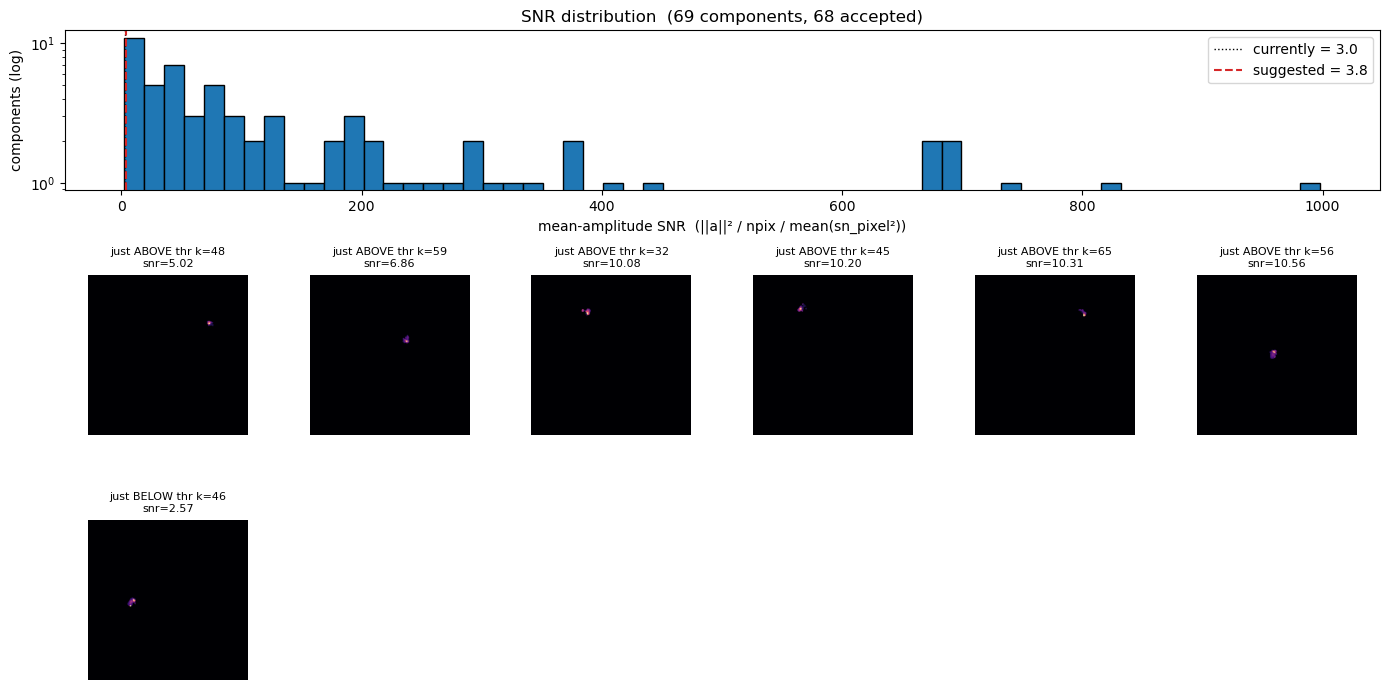


[suggested]  auto_eval_snr_amp_thr = 3.8  (largest gap in snr<10 region)


In [15]:
eval_info = getattr(model, 'eval_info', None)
assert eval_info is not None and 'snr_amp' in eval_info, (
    'no eval_info on model; re-run model.evaluate() before this cell'
)
snr = np.asarray(eval_info['snr_amp'], dtype=float)
current_thr = float(params_used.auto_eval_snr_amp_thr)

# Largest gap among components with snr < 10 — that's the ghost–real boundary.
low = np.sort(snr[snr < 10])
if len(low) >= 2:
    gaps = np.diff(low)
    j = int(np.argmax(gaps))
    snr_suggested = float(round((low[j] + low[j + 1]) / 2, 1))
else:
    snr_suggested = current_thr

# Footprint montage: 6 just above, 6 just below the current threshold.
H_dim, W_dim = model.dims
A_dense = np.asarray(model.A.todense()).reshape(H_dim, W_dim, K)
above = np.where(snr >= current_thr)[0]
below = np.where(snr <  current_thr)[0]
above_sel = above[np.argsort(snr[above])[:6]]              # smallest accepted
below_sel = below[np.argsort(-snr[below])[:6]]             # largest rejected

fig = plt.figure(figsize=(14, 7))
ax_h = plt.subplot2grid((3, 6), (0, 0), colspan=6)
ax_h.hist(snr[snr < np.percentile(snr, 99)], bins=60,
          color='C0', edgecolor='k')
ax_h.set_yscale('log')
ax_h.axvline(current_thr, color='k', ls=':', lw=1.0,
             label=f'currently = {current_thr:.1f}')
ax_h.axvline(snr_suggested, color='C3', ls='--', lw=1.5,
             label=f'suggested = {snr_suggested:.1f}')
ax_h.set_xlabel('mean-amplitude SNR  (||a||² / npix / mean(sn_pixel²))')
ax_h.set_ylabel('components (log)')
ax_h.set_title(f'SNR distribution  ({K} components, {int((snr >= current_thr).sum())} accepted)')
ax_h.legend()

def _show_row(axes_row, indices, title_prefix):
    for ax, k in zip(axes_row, indices):
        ax.imshow(A_dense[..., k], cmap='magma')
        ax.set_title(f'{title_prefix} k={k}\nsnr={snr[k]:.2f}', fontsize=8)
        ax.axis('off')
    for ax in axes_row[len(indices):]:
        ax.axis('off')

axes_above = [plt.subplot2grid((3, 6), (1, c)) for c in range(6)]
axes_below = [plt.subplot2grid((3, 6), (2, c)) for c in range(6)]
_show_row(axes_above, above_sel, 'just ABOVE thr')
_show_row(axes_below, below_sel, 'just BELOW thr')
plt.tight_layout()
plt.show()

print(f'\n[suggested]  auto_eval_snr_amp_thr = {snr_suggested}  '
      f'(largest gap in snr<10 region)')
suggested_params['auto_eval_snr_amp_thr'] = float(snr_suggested)

## Save suggestions as `params.json`

Pops the helper keys (`_ssub`, `_tsub`) into a separate file (they are not
`CNMFeParams` fields), builds a `CNMFeParams` from the remaining suggestions,
and dumps it. The result is ready for `run_mc.py --params params.json` /
`run_extract.py --params params.json --ds-meta ds_meta.json`.

In [16]:
# --- EDIT ME -----------------------------------------------------------------
OUT_DIR = Path('/tmp/cnmfe_estimated_params')
# -----------------------------------------------------------------------------

OUT_DIR.mkdir(parents=True, exist_ok=True)

to_save = dict(suggested_params)
ssub = to_save.pop('_ssub', 1)
tsub = to_save.pop('_tsub', 1)

# Drop any keys CNMFeParams doesn't know about so old/extra fields don't blow up.
from dataclasses import fields as _fields
valid = {f.name for f in _fields(CNMFeParams)}
filtered = {k: v for k, v in to_save.items() if k in valid}
dropped  = sorted(set(to_save) - set(filtered))
if dropped:
    print(f'(dropped non-CNMFeParams keys: {dropped})')

params = CNMFeParams(**filtered)
params.to_json(OUT_DIR / 'params.json')
(OUT_DIR / 'downsample.json').write_text(
    json.dumps({'ssub': int(ssub), 'tsub': int(tsub)}, indent=2)
)

print(f'wrote {OUT_DIR / "params.json"}')
print(f'wrote {OUT_DIR / "downsample.json"}  (ssub={ssub}, tsub={tsub})')
print('\nfinal suggestions:')
for k, v in sorted(filtered.items()):
    print(f'  {k:>26s} = {v}')

wrote /tmp/cnmfe_estimated_params/params.json
wrote /tmp/cnmfe_estimated_params/downsample.json  (ssub=2, tsub=1)

final suggestions:
       auto_eval_snr_amp_thr = 3.8
                   border_px = 6
               decay_time_ms = 2358.0
               frame_rate_hz = 10.0
              g_prior_weight = 0.3
                   max_shift = (6, 3)
                mc_gSig_filt = 5
              merge_thr_corr = 0.85
                    min_corr = 0.85
                   min_pixel = 65
                     min_pnr = 3.0
                       sigma = 2.0
